# PDI - TP 2 - A - RestAPI - Servidores sin control de estado - Gestión de la Base de Datos (Entrega: ver calendario en el GitHub)

## Pasos Previos

- Instalar SQLite.
  - Instalar Heidi SQL en Windows.
  - Para Linux y Windows se puede usar DBeaver Community Edition.
  - También se puede instalar DB Browser for SQLite.
   

- Desde una terminal crear la base de datos, si no existe SQLite la crea automáticamente.
  - La idea es crear un repositorio de datos para recibir datos de sensores.
  - Conectarse a la base de datos desde el gestor elegido.
  - Crear una tabla para recibir los datos de los sensores.
  - Verificar con el gestor o desde el SQLite desde una terminal que esté todo bien.
    

- Verificar que Python y pip esté instalado.
- Acceder a la base de datos de Python para ingresar nuevos valores.
- Desde el programa en Python importo las dependencias.
- Adaptar el código en github de acuerdo al criterio de diseño elegido.

- Notas: hubo varias consultas referidas a que no se desplegaban correctamente los datos.La idea de la versión r1 era que para el TP se adapte el código resolviendo las inconsistencias. Ahora podán encontrar las versiones r2 con algunas modificaciones.
  - sensores_r1 genera una db llamada datos_sendores.db
  - sensor_editar_tabla_r2 agrega nuevas rutas y mensajes.
    - @app.route('/api/prueba')
    - @app.route('/')
    - @app.route('/api/todos-los-datos')
    - @app.route('/api/primer-registro')
    - @app.route('/api/directorio-db')
    - @app.route('/api/insertar-dato')
- Verificar y mejorar.

### Es posible obtener datos reales del sensor Airlink instalado en la UCA: 
- http://calidadaire.uca.edu.ar
- Existe una opcion para descargar los datos en formato .csv   
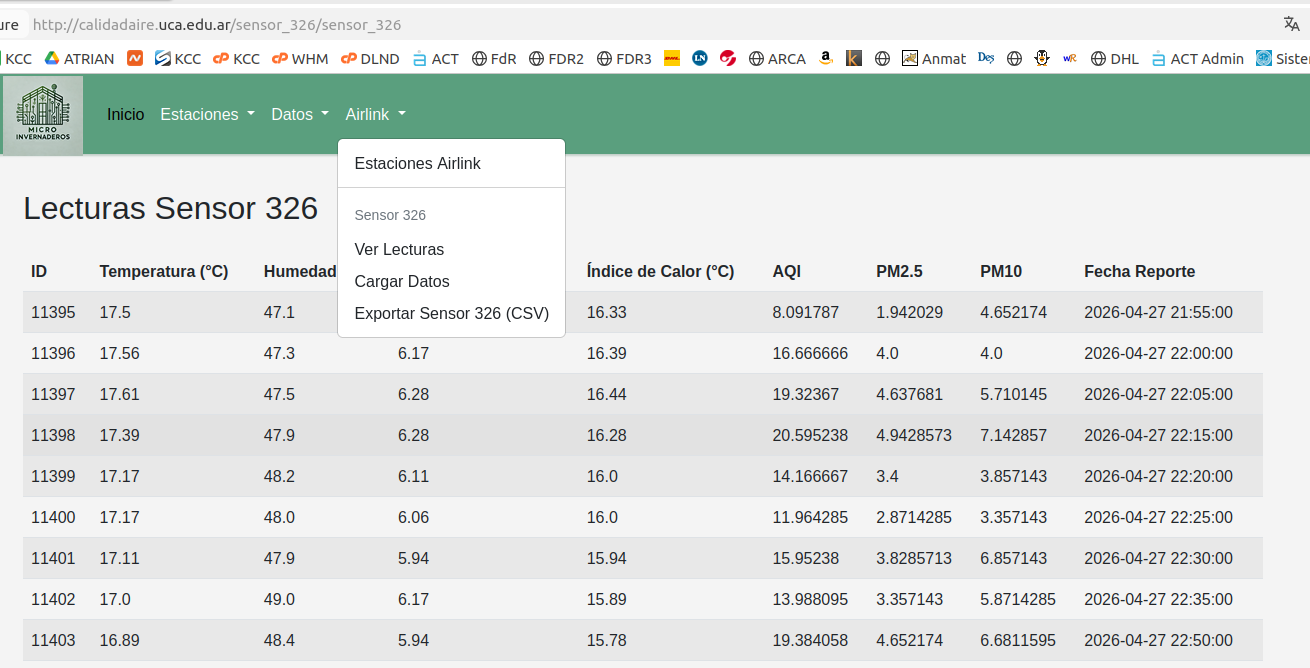

## Consigna del TP2 A. Desarrollo de Cliente - Servidor bajo Arquitectura Rest

1. Analizar la aplicación Flask básica. Explicar el funcionamiento de app = Flask(__name__), @app.route("/"), jsonify() y el modo debug=True, tomando como base Prueba_Flask_Routes_01.py.


2. Implementar una API REST de sensores.   
Desarrollar endpoints para listar sensores, consultar un sensor por id, crear un sensor, modificarlo y eliminarlo usando métodos GET, POST, PUT y DELETE.   


3. Corregir y mejorar el manejo de IDs   
Revisar el acceso directo a listas mediante sensors[id] y reemplazarlo por una búsqueda segura por campo id, devolviendo error 404 si no existe.


4. Comparar GET vs POST en Flask   
Implementar dos rutas de login: una con parámetros por URL y otra con formulario POST. Explicar diferencias de visibilidad, seguridad básica y uso correcto de request.args y request.form.


5. Persistir lecturas de sensores en SQLite   
Crear una tabla lectura_sensores con campos como co2, temp, hum, fecha, lugar, altura, presion, presion_nm y temp_ext, siguiendo la estructura usada en sensores_rx.py. 


6. Simular capturas de sensores ambientales   
Generar lecturas aleatorias de CO₂, temperatura y humedad; almacenarlas en la base de datos y permitir configurar cantidad de capturas e intervalo entre mediciones.


7. Integrar datos externos de clima   
Usar una función similar a geo_latlon() para obtener temperatura exterior, presión y humedad desde una API climática, y relacionar esos datos con las lecturas internas.   

8. Explicar las razones por la cual lo anterior es una Arquitectura CLiente Servidor Rest. Indicar si se cumplen los requisitos. Explicar dónde se definen el cliente y el servidor. Qué elementos faltan.

9. Comparar este modelo con el desarrollado en el TP1.

10. Desarrollar cliente visual WebSocket  
Crear una interfaz web que se conecte a un servidor WebSocket, muestre estado de conexión, permita enviar mensajes y visualice respuestas en tiempo real, según el notebook Cliente_Servidor_Websockets_R2.ipynb.   


In [4]:
%%writefile Prueba_Flask_Routes_01.py
from flask import Flask,jsonify

app = Flask(__name__)

sensors = [{'id':"0",
            'co2':"800",
            'temp':"23.0",
            'hum':"77.1",
            'fecha':"22/3/2021"},
           {'id': "1",
            'co2': "801",
            'temp': "24.0",
            'hum': "78.1",
            'fecha': "23/3/2021"}
           ]

@app.route('/')
def index():
    return "Hola"

@app.route("/sensors", methods=['GET'])
def get():
    return jsonify ({'Sensors':sensors})

@app.route("/sensors/<int:id>", methods=['GET'])
def get_measure(id):
    return jsonify ({'Sensors':sensors[id]})

@app.route("/sensors", methods=['POST'])
def create():
    sensor = [{'id': "2",
                'co2': "800",
                'temp': "23.0",
                'hum': "77.1",
                'fecha': "22/3/2021"}
               ]
    sensors.append(sensor)
    return jsonify ({'Created':sensor})

@app.route("/sensors/<int:id>", methods=['PUT'])
def sensor_update(id):
    sensors[id]['fecha'] = "22/9/2021"
    return jsonify ({'Sensor':sensors[id]})

@app.route("/sensors/<int:id>", methods=['DELETE'])
def sensor_delete(id):
    sensors.remove(sensors[id])
    return jsonify ({'result':True})

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5000, debug=True)

Overwriting Prueba_Flask_Routes_01.py


http://127.0.0.1:5000


In [10]:
%%writefile Prueba_Flask_Routes_02.py
from flask import Flask, jsonify, request

app = Flask(__name__)

sensors = [
    {
        "id": 0,
        "co2": 800,
        "temp": 23.0,
        "hum": 77.1,
        "fecha": "22/3/2021"
    },
    {
        "id": 1,
        "co2": 801,
        "temp": 24.0,
        "hum": 78.1,
        "fecha": "23/3/2021"
    }
]


@app.route("/")
def index():
    return """
    <!doctype html>
    <html lang="es">
    <head>
        <meta charset="utf-8">
        <meta name="viewport" content="width=device-width, initial-scale=1">
        <title>Flask Sensores</title>

        <link href="https://cdn.jsdelivr.net/npm/bootstrap@5.3.3/dist/css/bootstrap.min.css" rel="stylesheet">
    </head>

    <body class="bg-light">

    <nav class="navbar navbar-dark bg-dark mb-4">
        <div class="container">
            <span class="navbar-brand mb-0 h1">Servidor Flask - Sensores</span>
        </div>
    </nav>

    <div class="container">

        <div class="alert alert-success">
            Flask está funcionando correctamente en el puerto 5001.
        </div>

        <div class="row g-4">

            <div class="col-md-6">
                <div class="card shadow-sm">
                    <div class="card-header bg-primary text-white">
                        Login por POST
                    </div>
                    <div class="card-body">
                        <form action="/login" method="post">
                            <div class="mb-3">
                                <label class="form-label">Nombre</label>
                                <input type="text" name="nombre" class="form-control" placeholder="javier">
                            </div>

                            <div class="mb-3">
                                <label class="form-label">Clave</label>
                                <input type="password" name="clave" class="form-control" placeholder="abc">
                            </div>

                            <button type="submit" class="btn btn-primary">
                                Ingresar
                            </button>
                        </form>
                    </div>
                </div>
            </div>

            <div class="col-md-6">
                <div class="card shadow-sm">
                    <div class="card-header bg-success text-white">
                        Accesos rápidos
                    </div>
                    <div class="card-body">
                        <a href="/login_get?nombre=javier&clave=abc" class="btn btn-outline-primary mb-2 w-100">
                            Probar Login GET
                        </a>

                        <a href="/sensors" class="btn btn-outline-success mb-2 w-100">
                            Ver sensores JSON
                        </a>

                        <a href="/sensors/0" class="btn btn-outline-secondary mb-2 w-100">
                            Ver sensor 0
                        </a>

                        <a href="/sensors/1" class="btn btn-outline-secondary w-100">
                            Ver sensor 1
                        </a>
                    </div>
                </div>
            </div>

        </div>

        <div class="card mt-4 shadow-sm">
            <div class="card-header bg-dark text-white">
                Endpoints disponibles
            </div>
            <div class="card-body">
                <table class="table table-striped table-bordered">
                    <thead>
                        <tr>
                            <th>Método</th>
                            <th>Ruta</th>
                            <th>Descripción</th>
                        </tr>
                    </thead>
                    <tbody>
                        <tr>
                            <td><span class="badge bg-success">GET</span></td>
                            <td>/sensors</td>
                            <td>Lista todos los sensores</td>
                        </tr>
                        <tr>
                            <td><span class="badge bg-success">GET</span></td>
                            <td>/sensors/&lt;id&gt;</td>
                            <td>Consulta un sensor por ID</td>
                        </tr>
                        <tr>
                            <td><span class="badge bg-primary">POST</span></td>
                            <td>/sensors</td>
                            <td>Crea un nuevo sensor usando JSON</td>
                        </tr>
                        <tr>
                            <td><span class="badge bg-warning text-dark">PUT</span></td>
                            <td>/sensors/&lt;id&gt;</td>
                            <td>Actualiza un sensor</td>
                        </tr>
                        <tr>
                            <td><span class="badge bg-danger">DELETE</span></td>
                            <td>/sensors/&lt;id&gt;</td>
                            <td>Elimina un sensor</td>
                        </tr>
                        <tr>
                            <td><span class="badge bg-primary">POST</span></td>
                            <td>/post_json</td>
                            <td>Recibe datos JSON genéricos</td>
                        </tr>
                    </tbody>
                </table>
            </div>
        </div>

    </div>

    </body>
    </html>
    """


@app.route("/login", methods=["POST"])
def login_post():
    nombre = request.form.get("nombre")
    clave = request.form.get("clave")

    if nombre == "javier" and clave == "abc":
        return f"Hola {nombre} con POST"

    return "Usuario o clave incorrectos", 401


@app.route("/login_get", methods=["GET"])
def login_get():
    nombre = request.args.get("nombre")
    clave = request.args.get("clave")

    if nombre == "javier" and clave == "abc":
        return f"Hola {nombre} con GET"

    return "Usuario o clave incorrectos", 401


@app.route("/post_json", methods=["POST"])
def process_json():
    if not request.is_json:
        return jsonify({"error": "Content-Type no soportado. Use application/json"}), 415

    data = request.get_json()
    return jsonify({
        "mensaje": "JSON recibido correctamente",
        "datos": data
    })


@app.route("/sensors", methods=["GET"])
def get_sensors():
    return jsonify({"sensors": sensors})


@app.route("/sensors/<int:id>", methods=["GET"])
def get_sensor(id):
    for sensor in sensors:
        if sensor["id"] == id:
            return jsonify({"sensor": sensor})

    return jsonify({"error": "Sensor no encontrado"}), 404


@app.route("/sensors", methods=["POST"])
def create_sensor():
    if not request.is_json:
        return jsonify({"error": "Debe enviar datos en formato JSON"}), 415

    data = request.get_json()

    new_sensor = {
        "id": len(sensors),
        "co2": data.get("co2"),
        "temp": data.get("temp"),
        "hum": data.get("hum"),
        "fecha": data.get("fecha")
    }

    sensors.append(new_sensor)

    return jsonify({
        "mensaje": "Sensor creado correctamente",
        "sensor": new_sensor
    }), 201


@app.route("/sensors/<int:id>", methods=["PUT"])
def update_sensor(id):
    if not request.is_json:
        return jsonify({"error": "Debe enviar datos en formato JSON"}), 415

    data = request.get_json()

    for sensor in sensors:
        if sensor["id"] == id:
            sensor["co2"] = data.get("co2", sensor["co2"])
            sensor["temp"] = data.get("temp", sensor["temp"])
            sensor["hum"] = data.get("hum", sensor["hum"])
            sensor["fecha"] = data.get("fecha", sensor["fecha"])

            return jsonify({
                "mensaje": "Sensor actualizado correctamente",
                "sensor": sensor
            })

    return jsonify({"error": "Sensor no encontrado"}), 404


@app.route("/sensors/<int:id>", methods=["DELETE"])
def delete_sensor(id):
    for sensor in sensors:
        if sensor["id"] == id:
            sensors.remove(sensor)
            return jsonify({
                "mensaje": "Sensor eliminado correctamente",
                "result": True
            })

    return jsonify({"error": "Sensor no encontrado"}), 404


if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5001, debug=True)

Overwriting Prueba_Flask_Routes_02.py


In [13]:
%%writefile sensor_editar_tabla_r1A.py

from flask import Flask, render_template, request, abort, jsonify
from flask_sqlalchemy import SQLAlchemy
from decimal import Decimal

app = Flask(__name__)


# CONFIGURACION SQLITE

app.config["SQLALCHEMY_DATABASE_URI"] = "sqlite:///datos_sensores.db"
app.config["SQLALCHEMY_TRACK_MODIFICATIONS"] = False

db = SQLAlchemy(app)


# MODELO DE TABLA SQL


class LecturaSensores(db.Model):
    __tablename__ = "lectura_sensores"

    id = db.Column(db.Integer, primary_key=True)
    co2 = db.Column(db.Float)
    co2_corregido = db.Column(db.Numeric(precision=10, scale=2))
    temp = db.Column(db.Numeric(precision=10, scale=2))
    hum = db.Column(db.Numeric(precision=10, scale=2))
    fecha = db.Column(db.Text)
    lugar = db.Column(db.Text)
    altura = db.Column(db.Numeric(precision=8, scale=0))
    presion = db.Column(db.Numeric(precision=8, scale=2))
    presion_nm = db.Column(db.Numeric(precision=8, scale=2))
    temp_ext = db.Column(db.Numeric(precision=8, scale=2))
    temp_ref = db.Column(db.Numeric(precision=8, scale=2))

    def __repr__(self):
        return f"<Id {self.id}>"

    def to_dict(self):
        def convertir(valor):
            if isinstance(valor, Decimal):
                return float(valor)
            return valor

        return {
            "id": self.id,
            "co2": convertir(self.co2),
            "co2_corregido": convertir(self.co2_corregido),
            "temp": convertir(self.temp),
            "hum": convertir(self.hum),
            "fecha": self.fecha,
            "lugar": self.lugar,
            "altura": convertir(self.altura),
            "presion": convertir(self.presion),
            "presion_nm": convertir(self.presion_nm),
            "temp_ext": convertir(self.temp_ext),
            "temp_ref": convertir(self.temp_ref),
        }


# CREAR TABLAS SI NO EXISTEN


with app.app_context():
    db.create_all()


# PAGINA PRINCIPAL


@app.route("/")
def index():
    return render_template("tabla_sensores_para_editar.html")


# CONSULTAR DATOS CON FILTRO + PAGINACION + ORDEN


@app.route("/api/datos")
def datos():

    query = LecturaSensores.query

    search = request.args.get("search")
    if search:
        query = query.filter(LecturaSensores.lugar.like(f"%{search}%"))

    total = query.count()

    sort = request.args.get("sort", "id")

    allowed_columns = {
        "id": LecturaSensores.id,
        "lugar": LecturaSensores.lugar,
        "fecha": LecturaSensores.fecha,
        "co2": LecturaSensores.co2,
        "temp": LecturaSensores.temp,
        "hum": LecturaSensores.hum
    }

    if sort:
        descending = False

        if sort.startswith("-"):
            descending = True
            sort = sort[1:]

        column = allowed_columns.get(sort, LecturaSensores.id)

        if descending:
            column = column.desc()

        query = query.order_by(column)

    start = request.args.get("start", type=int, default=0)
    length = request.args.get("length", type=int, default=50)

    query = query.offset(start).limit(length)

    registros = query.all()

    return jsonify({
        "data": [r.to_dict() for r in registros],
        "total": total
    })


# CREAR NUEVO REGISTRO


@app.route("/api/data", methods=["POST"])
def create():

    data = request.get_json()

    if not data:
        abort(400)

    nuevo = LecturaSensores(
        co2=data.get("co2"),
        co2_corregido=data.get("co2_corregido"),
        temp=data.get("temp"),
        hum=data.get("hum"),
        fecha=data.get("fecha"),
        lugar=data.get("lugar"),
        altura=data.get("altura"),
        presion=data.get("presion"),
        presion_nm=data.get("presion_nm"),
        temp_ext=data.get("temp_ext"),
        temp_ref=data.get("temp_ref")
    )

    db.session.add(nuevo)
    db.session.commit()

    return jsonify({
        "mensaje": "Registro creado correctamente",
        "registro": nuevo.to_dict()
    }), 201


# ACTUALIZAR REGISTRO EXISTENTE


@app.route("/api/data/<int:id>", methods=["PUT"])
def update(id):

    data = request.get_json()

    if not data:
        abort(400)

    registro = LecturaSensores.query.get(id)

    if not registro:
        abort(404)

    campos_editables = [
        "co2",
        "co2_corregido",
        "temp",
        "hum",
        "fecha",
        "lugar",
        "altura",
        "presion",
        "presion_nm",
        "temp_ext",
        "temp_ref"
    ]

    for campo in campos_editables:
        if campo in data:
            setattr(registro, campo, data[campo])

    db.session.commit()

    return jsonify({
        "mensaje": "Registro actualizado correctamente",
        "registro": registro.to_dict()
    })


# BORRAR REGISTRO


@app.route("/api/data/<int:id>", methods=["DELETE"])
def delete(id):

    registro = LecturaSensores.query.get(id)

    if not registro:
        abort(404)

    db.session.delete(registro)
    db.session.commit()

    return jsonify({
        "mensaje": "Registro eliminado correctamente",
        "id": id
    })


# INSERCION AUTOMATICA DE DATOS DE PRUEBA (sólo primera vez)


@app.route("/cargar_demo")
def cargar_demo():

    if LecturaSensores.query.count() == 0:

        demo1 = LecturaSensores(
            co2=800,
            co2_corregido=798.25,
            temp=23.10,
            hum=77.10,
            fecha="22/03/2021",
            lugar="Laboratorio UCA",
            altura=15,
            presion=1009.55,
            presion_nm=1013.25,
            temp_ext=18.40,
            temp_ref=25.00
        )

        demo2 = LecturaSensores(
            co2=810,
            co2_corregido=807.80,
            temp=24.20,
            hum=75.00,
            fecha="23/03/2021",
            lugar="Aula 3",
            altura=12,
            presion=1008.20,
            presion_nm=1012.10,
            temp_ext=19.10,
            temp_ref=25.00
        )

        db.session.add(demo1)
        db.session.add(demo2)
        db.session.commit()

        return "Datos demo cargados"

    return "La base ya contiene datos"


# MAIN


if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5010, debug=True)

Overwriting sensor_editar_tabla_r1A.py


### Para este error:
    "error": "Error OpenWeatherMap: {'cod': 401, 'message': 'Invalid API key. Please see https://openweathermap.org/faq#error401 for more info.'}"

Crear cuenta en OpenWeather

Ir a:

https://home.openweathermap.org/users/sign_up

crear usuario.

Luego entrar a:

https://home.openweathermap.org/api_keys

y copiar la API key.


In [14]:
%%writefile sensor_editar_tabla_r1B_geo.py

import os
import random
import sqlite3
import requests
import geocoder

from datetime import datetime
from flask import Flask, render_template, jsonify, request


app = Flask(__name__)

DB_NAME = "db.datos_sensores"

# Mejor usar variable de entorno:
# export OPENWEATHER_API_KEY="TU_API_KEY"
OPENWEATHER_API_KEY = os.getenv("OPENWEATHER_API_KEY", "C2f66bd561ebc7e4bde0d2a8951df0098")



# BASE DE DATOS


def get_connection():
    return sqlite3.connect(DB_NAME)


def create_table():
    conn = get_connection()
    cursor = conn.cursor()

    cursor.execute("""
        CREATE TABLE IF NOT EXISTS lectura_sensores (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            co2 REAL,
            temp REAL,
            hum REAL,
            fecha TEXT,
            lugar TEXT,
            altura REAL,
            presion REAL,
            presion_nm REAL,
            temp_ext REAL,
            humedad_ext REAL,
            descripcion_clima TEXT
        )
    """)

    conn.commit()
    conn.close()


def obtener_registros():
    conn = get_connection()
    cursor = conn.cursor()

    cursor.execute("""
        SELECT 
            id,
            co2,
            temp,
            hum,
            fecha,
            lugar,
            altura,
            presion,
            presion_nm,
            temp_ext,
            humedad_ext,
            descripcion_clima
        FROM lectura_sensores
        ORDER BY id DESC
    """)

    rows = cursor.fetchall()
    conn.close()

    datos = []

    for r in rows:
        datos.append({
            "id": r[0],
            "co2": r[1],
            "temp": r[2],
            "hum": r[3],
            "fecha": r[4],
            "lugar": r[5],
            "altura": r[6],
            "presion": r[7],
            "presion_nm": r[8],
            "temp_ext": r[9],
            "humedad_ext": r[10],
            "descripcion_clima": r[11]
        })

    return datos



# GEOLOCALIZACION + CLIMA


def geo_latlon():
    g = geocoder.ip("me")

    if not g.latlng:
        raise Exception("No se pudo obtener la ubicación por IP")

    lat, lon = g.latlng

    url = (
        "https://api.openweathermap.org/data/2.5/weather?"
        f"lat={lat}&lon={lon}"
        f"&appid={OPENWEATHER_API_KEY}"
        "&units=metric"
        "&lang=es"
    )

    response = requests.get(url, timeout=10)
    data = response.json()

    if str(data.get("cod")) not in ["200"]:
        raise Exception(f"Error OpenWeatherMap: {data}")

    main = data["main"]
    weather = data["weather"][0]

    temp_ext = main["temp"]
    presion = main["pressure"]
    humedad_ext = main["humidity"]
    descripcion_clima = weather["description"]

    return {
        "lat": lat,
        "lon": lon,
        "temp_ext": temp_ext,
        "presion": presion,
        "humedad_ext": humedad_ext,
        "descripcion_clima": descripcion_clima
    }


def clima_por_ciudad(ciudad):
    url = (
        "https://api.openweathermap.org/data/2.5/weather?"
        f"q={ciudad}"
        f"&appid={OPENWEATHER_API_KEY}"
        "&units=metric"
        "&lang=es"
    )

    response = requests.get(url, timeout=10)
    data = response.json()

    if str(data.get("cod")) not in ["200"]:
        raise Exception(f"Ciudad no encontrada o error OpenWeatherMap: {data}")

    main = data["main"]
    weather = data["weather"][0]

    return {
        "lat": data["coord"]["lat"],
        "lon": data["coord"]["lon"],
        "temp_ext": main["temp"],
        "presion": main["pressure"],
        "humedad_ext": main["humidity"],
        "descripcion_clima": weather["description"]
    }



# SIMULACION DE SENSOR


def simular_lectura(lugar, altura, clima):
    temp_ext = float(clima["temp_ext"])
    presion = float(clima["presion"])

    co2_medido = random.uniform(250, 1100)
    temp_sensor = random.uniform(temp_ext, temp_ext + 10)
    humedad_relativa = random.uniform(40, 80)

    fecha = datetime.now().strftime("%d-%b-%Y (%H:%M:%S)")

    lectura = {
        "co2": round(co2_medido, 2),
        "temp": round(temp_sensor, 2),
        "hum": round(humedad_relativa, 2),
        "fecha": fecha,
        "lugar": lugar,
        "altura": altura,
        "presion": presion,
        "presion_nm": presion,
        "temp_ext": clima["temp_ext"],
        "humedad_ext": clima["humedad_ext"],
        "descripcion_clima": clima["descripcion_clima"]
    }

    return lectura


def insertar_lectura(lectura):
    conn = get_connection()
    cursor = conn.cursor()

    cursor.execute("""
        INSERT INTO lectura_sensores (
            co2,
            temp,
            hum,
            fecha,
            lugar,
            altura,
            presion,
            presion_nm,
            temp_ext,
            humedad_ext,
            descripcion_clima
        )
        VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
    """, (
        lectura["co2"],
        lectura["temp"],
        lectura["hum"],
        lectura["fecha"],
        lectura["lugar"],
        lectura["altura"],
        lectura["presion"],
        lectura["presion_nm"],
        lectura["temp_ext"],
        lectura["humedad_ext"],
        lectura["descripcion_clima"]
    ))

    conn.commit()
    lectura["id"] = cursor.lastrowid
    conn.close()

    return lectura



# RUTAS WEB


@app.route("/")
def index():
    return render_template("tabla_sensores_geo.html")


@app.route("/api/datos")
def api_datos():
    return jsonify({
        "data": obtener_registros()
    })


@app.route("/api/clima")
def api_clima():
    ciudad = request.args.get("ciudad")

    try:
        if ciudad:
            clima = clima_por_ciudad(ciudad)
        else:
            clima = geo_latlon()

        return jsonify(clima)

    except Exception as e:
        return jsonify({
            "error": str(e)
        }), 500


@app.route("/api/capturar", methods=["POST"])
def api_capturar():
    data = request.get_json()

    if not data:
        return jsonify({"error": "Debe enviar JSON"}), 400

    lugar = data.get("lugar", "Sin definir")
    altura = float(data.get("altura", 0))
    ciudad = data.get("ciudad", "").strip()

    try:
        if ciudad:
            clima = clima_por_ciudad(ciudad)
        else:
            clima = geo_latlon()

        lectura = simular_lectura(lugar, altura, clima)
        lectura = insertar_lectura(lectura)

        return jsonify({
            "mensaje": "Lectura capturada correctamente",
            "lectura": lectura
        }), 201

    except Exception as e:
        return jsonify({
            "error": str(e)
        }), 500


@app.route("/api/data/<int:id>", methods=["DELETE"])
def borrar(id):
    conn = get_connection()
    cursor = conn.cursor()

    cursor.execute("DELETE FROM lectura_sensores WHERE id = ?", (id,))
    conn.commit()

    borrados = cursor.rowcount
    conn.close()

    if borrados == 0:
        return jsonify({"error": "Registro no encontrado"}), 404

    return jsonify({
        "mensaje": "Registro eliminado",
        "id": id
    })



# MAIN


if __name__ == "__main__":
    create_table()
    app.run(host="0.0.0.0", port=5012, debug=True)

Writing sensor_editar_tabla_r1B_geo.py
